# Customer Segmentation Using Unsupervised Learning

Objective: Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [2]:
#Load the Dataset
df = pd.read_csv("Mall_Customers.csv")

In [3]:
#Understanding the Dataset
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df.rename(columns={"Genre": "Gender"}, inplace=True)

In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


### Exploratory Data Analysis (EDA)

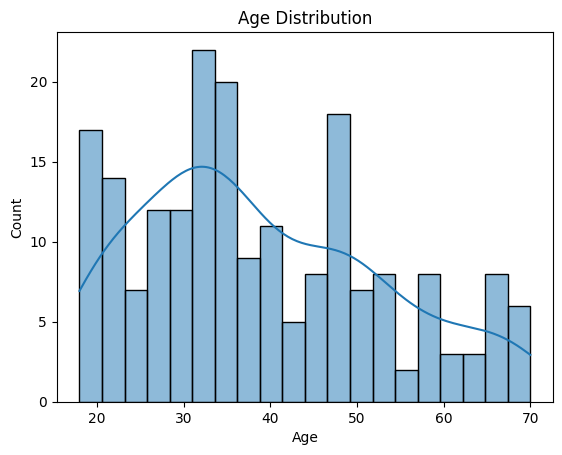

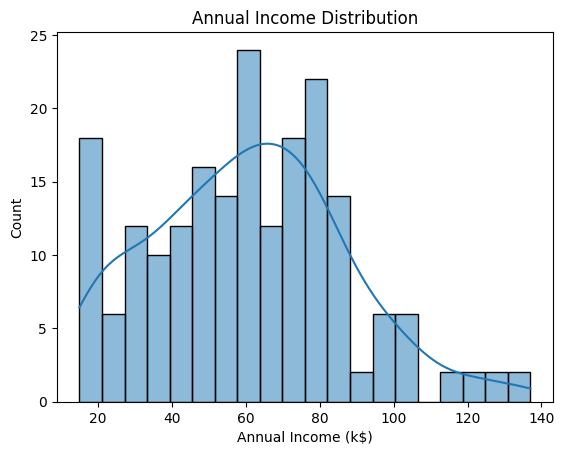

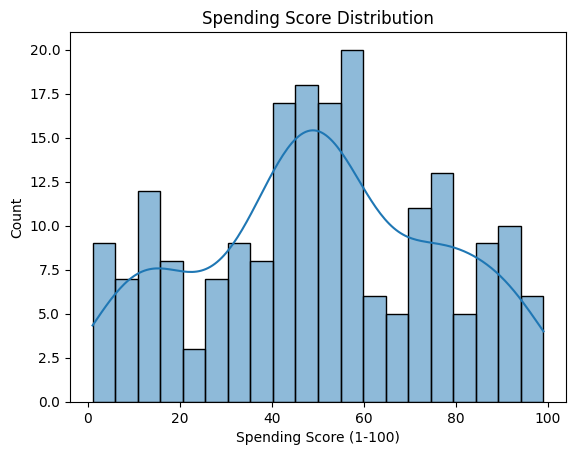

In [8]:
#Distribution Plots
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

#### Age Distribution:
The x-axis represents customer age.<br>
The y-axis represents the number of customers within each age range.<br>
The age distribution histogram shows a bimodal pattern with major peaks around ages 30–33 and 47–48. The dataset is slightly right-skewed, indicating that younger customers dominate the population, while older customers appear less frequently. <br>


#### Annual Income Distribution:
The x-axis represents annual income (in thousands of dollars). <br>
The y-axis shows the number of customers within each income range.<br>
The annual income distribution shows a concentration of customers within the middle-income range, particularly between $55k and $85k. The highest frequency occurs around $60k – $70k, indicating that the majority of customers are middle-class consumers. The distribution is moderately right-skewed, with very few customers earning above $100k.<br>

#### Spending Score Distribution:
The spending score distribution is approximately bell-shaped, with the highest concentration of customers scoring between 40 and 60. This indicates that moderate spenders form the largest customer segment

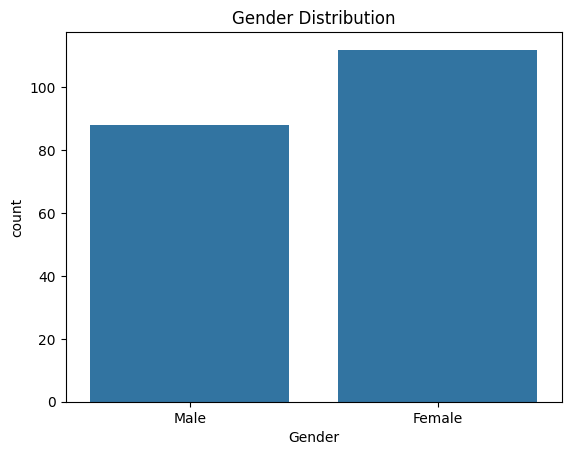

In [9]:
#Gender Distribution
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

##### Gender Distribution:
**Female Customers Are the Majority**
The gender distribution chart shows that female customers slightly outnumber male customers, accounting for approximately 56% of the dataset. While the imbalance is moderate, it suggests that female shoppers may visit the mall more frequently or engage more actively in retail activities.

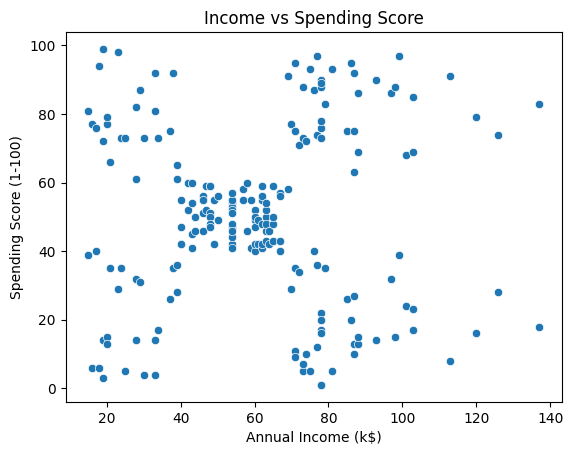

In [10]:
#Income vs Spending Score
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

X-Axis → Annual Income  : Represents customer yearly income in thousands of dollars. Example: 20 = 20,000 dollars<br>
Y-Axis → Spending Score (1–100) : Represents how much a customer spends in the mall.
Score is assigned by the mall based on purchasing behavior,higher score means customer spends more frequently or buys more expensive products.<br>

The scatter plot of Annual Income vs Spending Score reveals distinct customer behavior patterns. Customers are distributed into approx 5 visible groups:
##### 1. High Income + High Spending Customers (Upper-right region)
Income: High | Spending Score: High<br>
These customers earn a lot and spend a lot. These are the mall’s best customers. <br>

##### 2. High Income + Low Spending Customers (Lower-right region)
Income: High | Spending Score: Low<br>
These customers have strong purchasing power but spend less at the mall.<br>

##### 3. Low Income + High Spending Customers  (Upper-left region)
Income: Low | Spending Score: High<br>
These customers spend heavily despite lower income.They are highly responsive to promotions.<br>

##### 4. Low Income + Low Spending Customers  (Lower-left region)
Income: Low | Spending Score: Low<br>
These customers spend less and have limited purchasing capacity hence generating lower revenue.<br>

##### 5. Medium Income + Medium Spending Customers  (Center region)
Moderate income | Moderate spending<br>
This is the average customer group.<br>

The presence of clearly separable regions indicates that K-Means clustering is appropriate for identifying customer segments. The graph also demonstrates that higher income does not necessarily correspond to higher spending, highlighting the importance of behavior-based marketing strategies rather than income-based targeting alone.

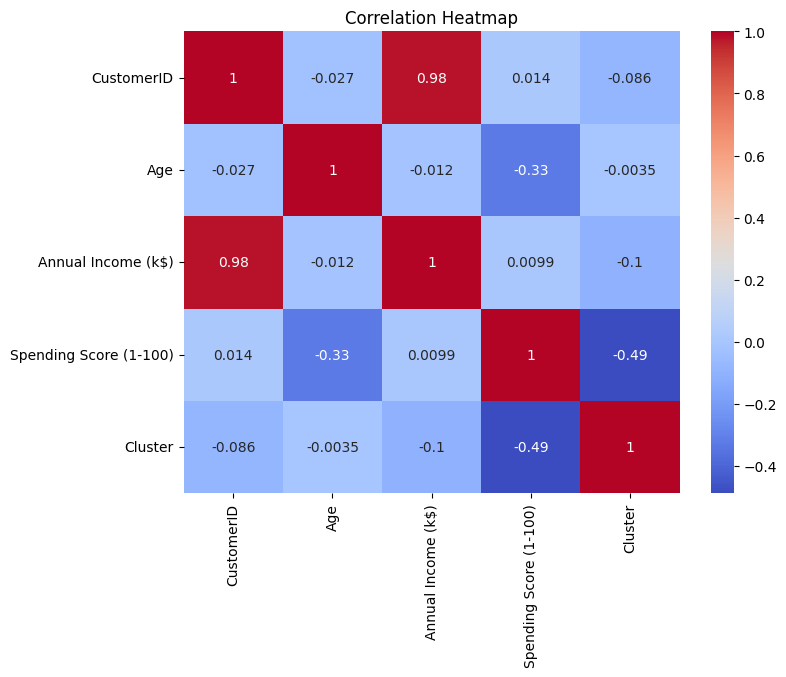

In [21]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Feature Selection & Scaling

In [12]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  #K-Means performs better with scaled data.

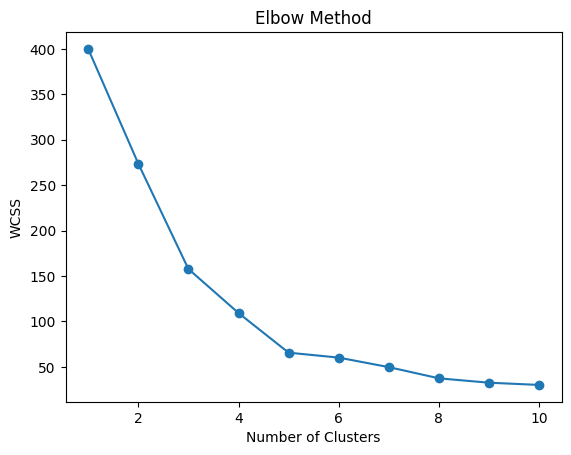

In [15]:
#Finding Optimal Number of Clusters
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

X-Axis → Number of Clusters (K): This represents the number of groups we want the algorithm to create.
Examples: K = 1 → all customers belong to one group, K = 5 → customers divided into 5 groups <br>

Y-Axis → WCSS: WCSS stands for: Within-Cluster Sum of Squares, it measures: how close data points are to their cluster center. <br>

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering. The graph shows the relationship between the number of clusters and the Within-Cluster Sum of Squares (WCSS). As the number of clusters increases, WCSS decreases because data points become closer to their respective centroids. However, after K=5, the rate of decrease becomes much smaller, forming an “elbow” in the graph. Therefore, K=5 was selected as the optimal number of customer segments for this project.


In [16]:
#Apply K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [17]:
#Evaluate Clustering
#Silhouette Score
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


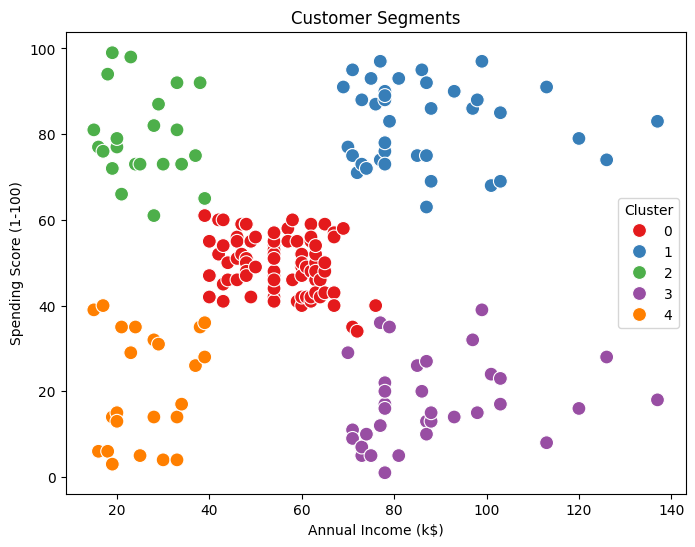

In [18]:
#Cluster Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)
plt.title("Customer Segments")
plt.show()

As stated above, this visualization represents the color-coded cluster seperation where:

0. Medium Income + Medium Spending Customers (Center region)
 
1. High Income + High Spending Customers (Upper-right region)

2. Low Income + High Spending Customers (Upper-left region)

3. High Income + Low Spending Customers (Lower-right region)

4. Low Income + Low Spending Customers (Lower-left region)


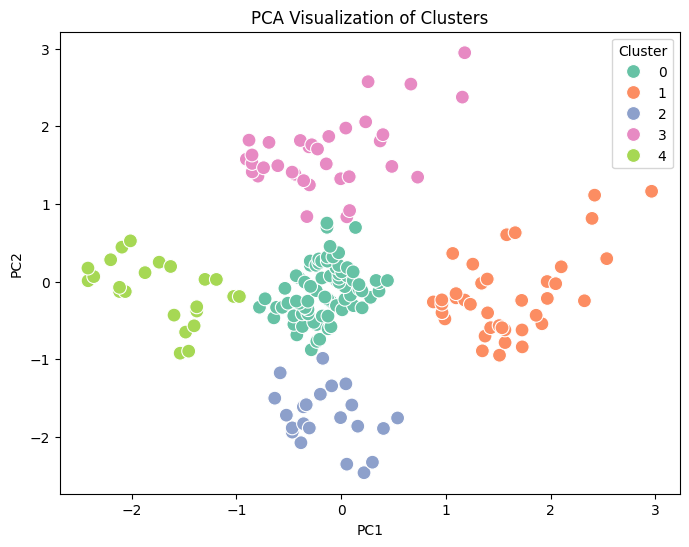

In [20]:
#PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2',
    data=pca_df,
    s=100
)
plt.title("PCA Visualization of Clusters")
plt.show()

##### PCA Visualization of Clusters:
Principal Component Analysis (PCA) is used to reduce complex, high-dimensional data into a simpler 2D representation while preserving the most important information in the dataset.

PC1 (X-Axis): Represents the direction with the maximum variation in customer behavior.<br>

PC2 (Y-Axis): Represents the second most important variation in the data. <br>

| Cluster | Color | Position | Notes |
|---------|-------|----------|-------|
| 0 | Teal | Center | Largest, densest cluster — core group |
| 1 | Orange | Right | Well-separated, moderate spread |
| 2 | Blue/Purple | Bottom-center | Tight, clearly separated below center |
| 3 | Pink/Magenta | Top-center | Spread out, some overlap with Cluster 0 |
| 4 | Green | Far left | Small, fairly isolated |

The scatter plot shows that most customer clusters are well separated, indicating effective segmentation by the K-Means algorithm. Some overlap exists between a few clusters, suggesting partial similarity in customer behavior.

## Key Business Insights:

1. Customer Base is Dominated by Young and Middle-Aged Adults, aged 20–35 & second concentration around: 45–50<br>

This indicates the presence of two major customer group:<br>
younger, trend-oriented shoppers & financially stable middle-aged customers<br>

The mall should implement age-specific marketing strategies:<br>
a)social media and fashion campaigns for younger customers<br>
b)premium and family-oriented offerings for middle-aged shoppers<br>

2. Middle-Income Customers Form the Largest Group around: $55k–$85k, while only a small number earn above: $100k<br>

The mall primarily serves middle-income consumers, which suggests:<br>
a)value-for-money products are highly important<br>
b)affordable premium products may perform well<br>
c)luxury-only strategies would target a smaller audience<br>

3. Spending Behavior is Diverse<br>

Most spending scores are concentrated around: 40–65<br>
This diversity makes customer segmentation highly valuable for targeted marketing.<br>

4. Income Does Not Directly Determine Spending<br>

The scatter plot analysis demonstrated that: some high-income customers spend very little & some lower-income customers spend heavily
Customer behavior cannot be predicted using income alone.<br>

Therefore: personalized marketing campaigns are necessary<br>

5. K-Means Successfully Identified Distinct Customer Segments<br>

The Elbow Method identified the optimal number of clusters as: K=5<br>
This indicates that the customer population naturally separates into five major groups.<br>

Different customer groups require different marketing approaches to maximize engagement and profitability.<br>

6. Female Customers Slightly Dominate the Dataset<br>

The gender distribution analysis showed: approximately 56% female customers & approximately 44% male customers<br>

Female shoppers may represent a slightly more active customer group in the mall environment.<br>

This provides opportunities for:<br>
a)fashion-focused promotions<br>
b)beauty and lifestyle campaigns<br>
c)loyalty-based engagement programs<br>


This project successfully applied:<br>
1)K-Means Clustering for customer segmentation<br>
2)Principal Component Analysis for cluster visualization<br>
to analyze customer behavior using the Mall Customers Dataset.<br>
<br>

The project also demonstrated that:<br>
spending behavior varies significantly across customers<br>
income alone does not determine purchasing patterns<br>
personalized marketing strategies are essential for business growth<br>

By leveraging these insights, businesses can develop targeted campaigns for different customer groups, leading to:<br>
a)improved customer satisfaction<br>
b)increased marketing efficiency<br>
c)optimize promotional strategies<br>
d)improved customer retention<br>
e)maximum revenue generation<br>
<br>
<br>
This project highlights the practical importance of unsupervised learning techniques in real-world business analytics and customer relationship management.